# Домашнее задание: Построение RAG-системы с трансформерными декодерами

В этом домашнем задании вы закрепите знания о трансформерных декодерах и архитектуре Retrieval-Augmented Generation (RAG). Мы пройдем путь от простого полнотекстового поиска до продвинутого пайплайна с переранжированием и использованием LLM для генерации ответа.

## Практический бизнес-кейс: "ВикиПомощник" для контент-агентства

Крупное контент-агентство ежедневно создает сотни экспертных статей, аналитических отчетов и образовательных материалов. Редакторы агентства постоянно работают с огромным объемом энциклопедической информации. Сейчас процесс проверки фактов и поиска нужных деталей в справочниках занимает у них до 30% рабочего времени. Ручной поиск неэффективен, а использование публичных LLM без контекста часто приводит к галлюцинациям в статьях.

Руководство агентства поставило задачу разработать внутренний инструмент "ВикиПомощник". Это RAG-система, которая должна принимать вопрос редактора, мгновенно находить наиболее релевантные абзацы в проверенной базе знаний (русскоязычной Википедии) и формировать точный, лаконичный ответ на основе найденного контекста.

Ожидаемый результат внедрения ML-решения — сокращение времени на фактчекинг в 3 раза и полное устранение фактологических ошибок в выпускаемых материалах за счет опоры на доверенные источники.

## Рекомендации по выполнению в Google Colab

Для выполнения заданий, связанных с нейросетевыми моделями (BGE-M3, BGE-Reranker, Qwen3.5-9B), настоятельно рекомендуется использовать GPU.
1. В верхнем меню выберите `Среда выполнения` -> `Сменить среду выполнения`.
2. В поле `Аппаратный ускоритель` выберите `T4 GPU`.

**Решение проблемы нехватки памяти (CUDA Out of Memory):**
Если вы столкнулись с ошибкой `CUDA out of memory`, попробуйте следующие шаги:
- Уменьшите размер батча (например, с 32 до 16 или 8) при получении эмбеддингов.
- Ограничьте максимальную длину последовательности токенов (`max_length`).
- Перезапустите среду выполнения (`Среда выполнения` -> `Перезапустить среду выполнения`).
- В коде можно использовать принудительную очистку кэша:
```python
import torch
import gc
torch.cuda.empty_cache()
gc.collect()
```

Не забудьте сохранить копию ноутбука на свой Google Drive перед началом работы (`Файл` -> `Сохранить копию на Google Диск`).

## Таблица распределения баллов

| Блок | Задание | Баллы |
|---|---|---|
| **Часть 1. Стандартное ДЗ** | | **50** |
| 1 | Загрузка и подготовка данных (SberQuAD) | 8 |
| 2 | Полнотекстовый поиск (BM25) | 10 |
| 3 | Семантический поиск (BGE-M3) | 12 |
| 4 | Оценка качества: BM25 vs Семантика | 8 |
| 5 | RAG с декодером (Qwen3.5-9B) | 7 |
| 6 | Оценка стоимости запросов | 5 |
| **Часть 2. Продвинутое ДЗ** | | **50** |
| 7 | Гибридный поиск (RRF) | 10 |
| 8 | Переранжирование (Cross-Encoder) | 12 |
| 9 | Полный пайплайн с переранжированием и LLM | 8 |
| 10 | Сравнительный анализ всех стратегий и замер скорости | 10 |
| 11 | Расширенная оценка стоимости запросов | 5 |
| 12 | Итоговые выводы | 5 |
| **Итого** | | **100** |


In [15]:
# Установка необходимых библиотек
!pip install -q datasets sentence-transformers faiss-cpu rank_bm25 openai tiktoken pandas matplotlib seaborn


## Блок 0: Формализация задачи

Прежде чем писать код, давайте формализуем нашу бизнес-задачу в терминах машинного обучения.
Бизнес-задача: Автоматизировать поиск фактов в базе знаний и формирование ответов на вопросы редакторов.
ML-задача: Построение пайплайна информационного поиска (Information Retrieval) и генерации текста (Text Generation).

Для оценки качества поиска мы будем использовать две метрики:
1. **Recall@K (Полнота)**: Доля запросов, для которых правильный ответ (ground truth) содержится хотя бы в одном из K найденных документов. Эта метрика критически важна для RAG, так как если нужной информации нет в контексте, LLM не сможет дать правильный ответ (или сгаллюцинирует).
2. **MRR@K (Mean Reciprocal Rank)**: Оценивает позицию первого релевантного документа в выдаче. Чем выше нужный документ, тем лучше, так как LLM обращают больше внимания на начало контекста (lost in the middle).

В RAG системах Recall обычно важнее Precision (точности), поскольку LLM способны отфильтровать нерелевантный шум в контексте, но не могут выдумать верный факт, если его вообще не передали в промпте.

---
# Часть 1. Стандартное ДЗ (50 баллов)


### Задание 1. Загрузка и подготовка данных (8 баллов)

Мы будем использовать датасет `kuznetsoffandrey/sberquad` — русскоязычный аналог популярного датасета SQuAD, собранный Сбером на основе статей Википедии.
Он содержит пары "контекст - вопрос - ответ".
В RAG системе уникальные тексты из поля `context` станут нашей базой знаний (корпусом документов), `question` — запросами пользователей, а `answers` мы будем использовать для автоматической оценки качества поиска.

**Что нужно сделать:**
1. Выполните предоставленный код загрузки датасета.
2. Напишите код для извлечения всех уникальных текстов из поля `context`. Это будет наш корпус документов. Сохраните их в список `corpus`.
3. Сформируйте словарь соответствия: `doc_id` -> `text`.
4. Подготовьте тестовую выборку: выберите 200 случайных вопросов из датасета. Для каждого вопроса сохраните сам текст вопроса и правильный ответ (из `answers['text'][0]`).
5. В комментариях кратко объясните, почему важно дедуплицировать контексты при создании базы знаний.


In [16]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import random

# Загрузка датасета (используем только validation split для скорости)
dataset = load_dataset("kuznetsoffandrey/sberquad", split="validation")
df = pd.DataFrame(dataset)
print(f"Загружено {len(df)} записей.")

# === ВАШ КОД ЗДЕСЬ ===
# 1. Извлеките уникальные контексты в список corpus
corpus = df['context'].unique().tolist()
print(f"Количество записей:{len(df)}")
print(f"Количество записей после очистки:{len(corpus)}")

# 2. Создайте словарь doc_id -> text (индексы от 0 до len(corpus)-1)
corpus_dict = {doc_id:text for doc_id,text in enumerate(corpus)}
print(f"1={corpus_dict[0]}")
print(f"2={corpus_dict[1]}")
# 3. Подготовьте 200 случайных тестовых вопросов
# Формат test_queries: список словарей [{'question': text, 'ground_truth': text}]
random.seed(123)
test_indices = random.sample(range(len(df)), 200)

test_queries = []
for i in test_indices:
    row = df.iloc[i]
    question = row['question']
    ground_truth = row['answers']['text'][0]

    test_queries.append({
        'question': question,
        'ground_truth': ground_truth
    })

print(f"Подготовлено {len(test_queries)} тестовых запросов.")
print(f"Пример тестового запроса:")
print(f"Вопрос: {test_queries[0]['question']}")
print(f"Ответ: {test_queries[0]['ground_truth']}")
# === КОНЕЦ ВАШЕГО КОДА ===

print(f"Размер уникального корпуса: {len(corpus)} документов.")
print(f"Количество тестовых запросов: {len(test_queries)}")


Загружено 5036 записей.
Количество записей:5036
Количество записей после очистки:3971
1=Первые упоминания о строении человеческого тела встречаются в Древнем Египте. В XXVII веке до н. э. египетский врач Имхотеп описал некоторые органы и их функции, в частности головной мозг, деятельность сердца, распространение крови по сосудам. В древнекитайской книге Нейцзин (XI—VII вв. до н. э.) упоминаются сердце, печень, лёгкие и другие органы тела человека. В индийской книге Аюрведа ( Знание жизни , IX-III вв. до н. э.) содержится большой объём анатомических данных о мышцах, нервах, типах телосложения и темперамента, головном и спинном мозге.
2=Телескоп имеет модульную структуру и содержит пять отсеков для оптических приборов. Один из отсеков в течение долгого времени (1993—2009 годы) занимала корректирующая оптическая система (COSTAR), установленная во время первой экспедиции обслуживания в 1993 году для компенсации неточности изготовления главного зеркала. Поскольку все приборы, установленные 

### Задание 2. Полнотекстовый поиск (BM25) (10 баллов)

BM25 (Best Matching 25) — это классический алгоритм полнотекстового поиска, основанный на TF-IDF.
Он учитывает частоту термина в документе (TF), редкость термина во всем корпусе (IDF) и нормализует результат по длине документа. BM25 отлично ищет по точным совпадениям ключевых слов.

**Что нужно сделать:**
1. Токенизируйте корпус (разбейте тексты на слова, например, по пробелам и приведя к нижнему регистру).
2. Инициализируйте объект `BM25Okapi` из библиотеки `rank_bm25`.
3. Реализуйте функцию `search_bm25(query, k=5)`, которая принимает запрос, токенизирует его и возвращает список ID топ-K наиболее релевантных документов.


In [17]:
from rank_bm25 import BM25Okapi

# === ВАШ КОД ЗДЕСЬ ===
# 1. Токенизация корпуса
tokenized_corpus = [doc.lower().split() for doc in corpus]

# 2. Инициализация BM25
bm25 = BM25Okapi(tokenized_corpus)

# 3. Функция поиска
def search_bm25(query, k=5):
    """
    Возвращает список из K идентификаторов (индексов в corpus) наиболее релевантных документов.
    """
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_k_indices=sorted(range(len(scores)),key=lambda i:scores[i],reverse=True)[:k]
    return top_k_indices

# Проверка работы
sample_query = "В каком году был основан Московский университет?"
print(f"Запрос: {sample_query}")
top_docs = search_bm25(sample_query, k=3)
for doc_id in top_docs:
  print(f"Ответ:{corpus[doc_id][:100]}...")
# === КОНЕЦ ВАШЕГО КОДА ===



Запрос: В каком году был основан Московский университет?
Ответ:В середине 1930-х годов иракское правительство решило создать ряд банков для того, чтобы сделать кре...
Ответ:В 2001 году Deutsche Bank открыл в Москве Центр Разработки ПО, который специализируется на создании ...
Ответ:Наивысшего расцвета княжество достигло в конце XVI — начале XVII века. При архиепископах Вольфе Дитр...


### Задание 3. Семантический поиск (BGE-M3) (12 баллов)

Полнотекстовый поиск не понимает синонимов и опечаток. Эту проблему решает семантический поиск с использованием Bi-Encoder архитектуры.
Обе башни энкодера (для документа и для запроса) превращают текст в плотный вектор (эмбеддинг). Релевантность оценивается косинусным расстоянием между векторами.
Мы будем использовать модель `BAAI/bge-m3`, которая отлично работает с русским языком. Для быстрого поиска по векторам применим библиотеку FAISS.

**Что нужно сделать:**
1. Загрузите модель `BAAI/bge-m3` через `SentenceTransformer`.
2. Получите эмбеддинги для всего корпуса `corpus` (это может занять несколько минут на GPU).
3. Создайте FAISS индекс `IndexFlatIP` (внутреннее произведение, что эквивалентно косинусной близости для нормализованных векторов).
4. Добавьте нормализованные векторы корпуса в индекс.
5. Реализуйте функцию `search_semantic(query, k=5)`, которая векторизует запрос, нормализует вектор и ищет топ-K в FAISS.


In [5]:
!pip install faiss-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 MB 6.5 MB/s eta 0:00:00


In [6]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

print("Загрузка модели BGE-M3...")
# Используем SentenceTransformer для удобства
embedder = SentenceTransformer('BAAI/bge-m3')

# === ВАШ КОД ЗДЕСЬ ===
# 1. Получение эмбеддингов корпуса (используйте batch_size=16 или 32)
corpus_embeddings = embedder.encode(
    corpus,
    batch_size=16,
    show_progress_bar=True,
    normalize_embeddings=False
)
print(f"Размерность эмбеддингов: {corpus_embeddings.shape}")
print(f"Тип данных: {corpus_embeddings.dtype}")
# 2. Нормализация векторов (важно для косинусного расстояния в FAISS)
corpus_embeddings = corpus_embeddings.astype(np.float32)
faiss.normalize_L2(corpus_embeddings)

# 3. Создание и заполнение FAISS индекса
dimension = embedder.get_sentence_embedding_dimension()
index = faiss.IndexFlatIP(dimension)
index.add(corpus_embeddings)

print(f"   Размерность: {dimension}")
print(f"   Количество векторов: {index.ntotal}")


# 4. Функция семантического поиска
def search_semantic(query, k=5):
    """
    Возвращает список из K идентификаторов наиболее релевантных документов.
    """
    query_with_instruction="Represent this sentence for searching relevant passages:"+query
    query_embedding = embedder.encode(
        [query_with_instruction],
        normalize_embeddings=False
    )

    query_embedding=query_embedding.astype(np.float32)
    faiss.normalize_L2(query_embedding)
    scores, indicies = index.search(query_embedding,k)
    return indicies[0].tolist()

#Проверка работы
top_docs = search_semantic(sample_query, k=3)
for doc_id in top_docs:
  print(f"- {corpus[doc_id][:100]}...")
# === КОНЕЦ ВАШЕГО КОДА ===



Загрузка модели BGE-M3...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Batches:   0%|          | 0/249 [00:00<?, ?it/s]

Размерность эмбеддингов: (3971, 1024)
Тип данных: float32
   Размерность: 1024
   Количество векторов: 3971
- С 1804 по 1835 год в составе Московского университета и других российских университетов работал факу...
- В 1687 году в Москве была организована первая высшая школа — Славяно-греко-латинская академия, котор...
- Некоторые авторы считают, что распространение университетов в средневековой Европе было связано с Ре...


/tmp/ipykernel_2415/2489530975.py:24: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dimension = embedder.get_sentence_embedding_dimension()


### Задание 4. Оценка качества: BM25 vs Семантика (8 баллов)

Теперь давайте количественно сравним два подхода на нашей отложенной тестовой выборке из 200 вопросов.
Ниже предоставлена функция оценки. Она считает, что документ релевантен, если подстрока `ground_truth` (правильный ответ) содержится в тексте найденного документа.

**Что нужно сделать:**
1. Изучите код функции `evaluate_retriever`.
2. Запустите оценку для `search_bm25` и `search_semantic` с `k=5`.
3. Постройте столбчатую диаграмму (bar chart) для наглядного сравнения метрик Recall@5 и MRR@5 двух алгоритмов.


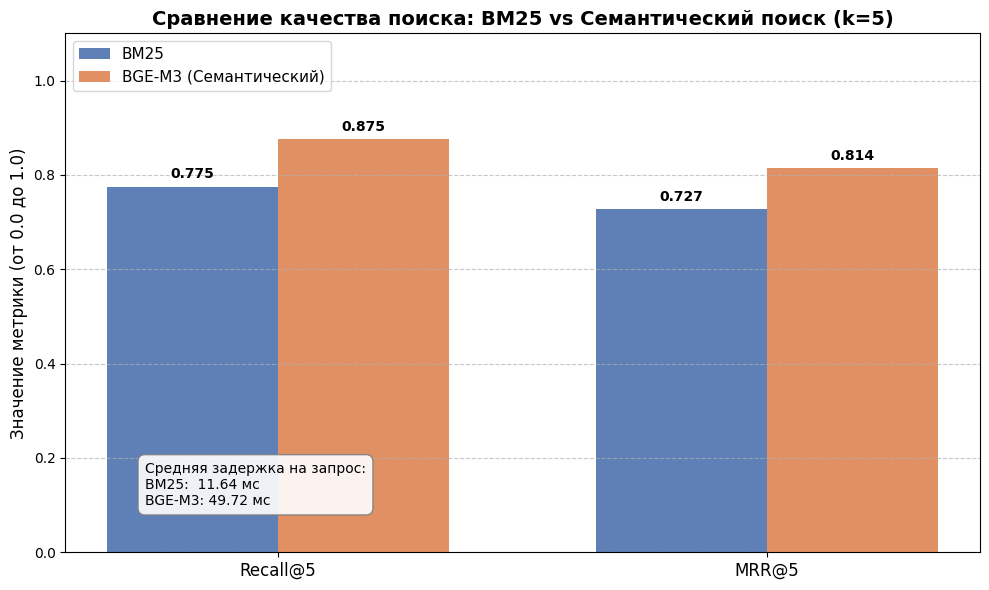

In [7]:
import time
import matplotlib.pyplot as plt

def evaluate_retriever(search_func, queries_data, corpus, k=5):
    recall_hits = 0
    mrr_sum = 0
    start_time = time.time()

    for item in queries_data:
        query = item['question']
        ground_truth = item['ground_truth'].lower()

        retrieved_ids = search_func(query, k=k)

        hit_rank = None
        for rank, doc_id in enumerate(retrieved_ids):
            doc_text = corpus[doc_id].lower()
            if ground_truth in doc_text:
                hit_rank = rank + 1
                break

        if hit_rank is not None:
            recall_hits += 1
            mrr_sum += 1.0 / hit_rank

    latency = time.time() - start_time

    recall = recall_hits / len(queries_data)
    mrr = mrr_sum / len(queries_data)
    avg_latency_ms = (latency / len(queries_data)) * 1000

    return {"Recall@K": recall, "MRR@K": mrr, "Latency_ms": avg_latency_ms}

# === ВАШ КОД ЗДЕСЬ ===
# 1. Запуск оценки
bm25_metrics = evaluate_retriever(search_bm25, test_queries, corpus, k=5)
semantic_metrics = evaluate_retriever(search_semantic, test_queries, corpus, k=5)

# 2. Визуализация результатов (matplotlib или seaborn)
metrics_names = ['Recall@5', 'MRR@5']
bm25_values = [bm25_metrics['Recall@K'], bm25_metrics['MRR@K']]
semantic_values = [semantic_metrics['Recall@K'], semantic_metrics['MRR@K']]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, bm25_values, width, label='BM25', color='#4C72B0', alpha=0.9)
rects2 = ax.bar(x + width/2, semantic_values, width, label='BGE-M3 (Семантический)', color='#DD8452', alpha=0.9)

ax.set_ylabel('Значение метрики (от 0.0 до 1.0)', fontsize=12)
ax.set_title('Сравнение качества поиска: BM25 vs Семантический поиск (k=5)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

latency_text = (f"Средняя задержка на запрос:\n"
                f"BM25:  {bm25_metrics['Latency_ms']:.2f} мс\n"
                f"BGE-M3: {semantic_metrics['Latency_ms']:.2f} мс")

plt.figtext(0.15, 0.15, latency_text, fontsize=10,
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()
# === КОНЕЦ ВАШЕГО КОДА ===



Cемантический поиск немного жертвует частью скорости , но дает существенный прирост в качестве поиска (Recall и MRR), так как может уловить смысловую близость , а не только совпадения по лексике .

### Задание 5. RAG с декодером (Qwen3.5-9B) (7 баллов)

Поиск — это только половина RAG. Вторая половина — генерация ответа с помощью декодерной LLM.
Мы будем использовать модель `Qwen/Qwen3.5-9B-Instruct`. Вы можете вызывать ее через API (например, бесплатный OpenRouter) или загрузить локально, если позволяет видеопамять.

**Что нужно сделать:**
1. Реализуйте функцию `generate_answer(query, context_docs)`, которая формирует промпт (инструкция + контексты + вопрос) и вызывает LLM для получения ответа.
2. Напишите обертку `rag_pipeline(query, search_func, k=3)`, которая сначала ищет документы, а затем генерирует ответ.
3. Протестируйте ваш пайплайн на 3-5 любых вопросах (можно придумать свои), используя семантический поиск. Выведите вопрос, найденный контекст и ответ LLM.


In [8]:
import os
import torch
from transformers import pipeline

print("2. Загрузка модели...")
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

llm = pipeline(
    "text-generation",
    model=model_name,
    model_kwargs={
        "torch_dtype": torch.float16,
        "device_map": "auto"
    },
    trust_remote_code=True
)
print(f"Модель {model_name} успешно загружена.\n")

def generate_answer(query, context_docs):
    prompt = f"Используй только следующий контекст для ответа на вопрос.\nКонтекст:\n{context_docs}\n\nВопрос: {query}\nОтвет:"

    messages = [
        {"role": "system", "content": "Ты полезный ассистент. Отвечай строго на основе предоставленного контекста."},
        {"role": "user", "content": prompt}
    ]

    outputs = llm(
        messages,
        max_new_tokens=150,
        temperature=0.1,
        do_sample=False,
        return_full_text=False
    )

    answer = outputs[0]["generated_text"].strip()
    return answer

def rag_pipeline(query, search_func, k=3):
    print(f"Ищем и генерируем для: '{query}'")
    doc_ids = search_func(query, k=k)
    context_docs = "\n\n".join([f"[{i+1}] {corpus[doc_id]}" for i, doc_id in enumerate(doc_ids)])
    answer = generate_answer(query, context_docs)
    return {"question": query, "context": context_docs, "answer": answer}

test_questions = [
    "Кто написал роман «Война и мир»?",
    "Что такое фотосинтез?",
    "Какая планета является самой большой в Солнечной системе?",
    "Какова численность населения нашей планеты?",
    "Какая самая длинная река в мире?"
]

for i, q in enumerate(test_questions, 1):
    print(f"\n--- Вопрос {i}/{len(test_questions)} ---")
    result = rag_pipeline(q, search_semantic, k=3)

    ctx_preview = result['context'][:150] + "..." if len(result['context']) > 150 else result['context']
    print(f"Контекст: {ctx_preview}")
    print(f"Ответ: {result['answer']}")


2. Загрузка модели...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

...

Контекст: [1] Фотосинтез бактерий может быть двух типов — бескислородный, с использованием бактериохлорофилла (зелёные, пурпурные и гелиобактерии) и кислородный...
Ответ: Фотосинтез - процесс, при котором живые организмы преобразуют энергию света в химическую энергию путём фотосинтезирования органических веществ. Он происходит у многих видов растений, бактерий и архей, используя хлорофилл или бактериохлорофилл для этого цели.

--- Вопрос 3/5 ---
Ищем и генерируем для: 'Какая планета является самой большой в Солнечной системе?'


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Контекст: [1] В области Большой Медведицы много галактик и их скоплений. Спиральная галактика М 101 видна плашмя, а спиральная М 81 и веретенообразная М 82, раз...
Ответ: Самая большая планета в Солнечной системе - это Меркурий.

--- Вопрос 4/5 ---
Ищем и генерируем для: 'Какова численность населения нашей планеты?'


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Контекст: [1] Перепись населения США 2000 года выделила следующие группы племён (этногруппы) эскимосов: юпикские народы, говорящие на языках юпик (Yup’ik: 24237...
Ответ: На основании данных, которые были предоставлены, мы можем сделать вывод, что общая численность населения нашей планеты не может быть определена точно из этих источников. Эти данные относятся к конкретным группам людей, таких как эскимосы, саамы и другие этнические группы, но они не покрывают все человечество. Также стоит отметить, что эти данные могут быть обновлены со временем, поэтому актуальную информацию можно найти в специализированных источниках.

--- Вопрос 5/5 ---
Ищем и генерируем для: 'Какая самая длинная река в мире?'
Контекст: [1] Одна из крупнейших рек мира: длина реки от места слияния Большого Енисея и Малого Енисея — 3487 км (с Малым Енисеем — 4287 км, от истоков Большого...
Ответ: Самой длинной рекой в мире является Енисей. Она имеет длину около 4123 километра.


### Задание 6. Оценка стоимости запросов (5 баллов)

В коммерческой разработке важно понимать экономику продукта. Провайдеры API тарифицируют токены (входные и выходные).
Размер входного промпта напрямую зависит от количества передаваемых чанков (найденных документов) и их длины. Длина ответа контролируется системным промптом.

**Что нужно сделать:**
1. Используя библиотеку `tiktoken` (энкодер `cl100k_base` близок к большинству современных LLM), напишите функцию `estimate_cost(query, retrieved_docs, max_output_tokens)`.
2. Предположим тариф: $0.50 за 1M входных токенов и $1.50 за 1M выходных токенов.
3. Посчитайте среднюю стоимость 1000 запросов для трех сценариев:
   - k=1 (передаем 1 документ), короткий ответ (max 50 токенов)
   - k=3 (передаем 3 документа), средний ответ (max 150 токенов)
   - k=5 (передаем 5 документов), развернутый ответ (max 300 токенов)
4. В качестве запроса и документов используйте усредненные длины из вашего тестового набора.


In [9]:
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

# === ВАШ КОД ЗДЕСЬ ===
def estimate_cost(query_text, docs_texts, max_output_tokens):
    """
    Возвращает стоимость одного запроса в долларах.
    """
    context = "\n\n".join([f"[Документ {i+1}]: {doc}" for i, doc in enumerate(docs_texts)])
    system_prompt = "Ты полезный ассистент. Отвечай строго на основе предоставленного контекста.\n"
    full_prompt = f"{system_prompt}Используй только следующий контекст для ответа на вопрос.\nКонтекст:\n{context}\n\nВопрос: {query_text}\nОтвет:"

    input_tokens = encoding.encode(full_prompt)
    num_input_tokens = len(input_tokens)

    input_cost = (num_input_tokens / 1_000_000) * 0.50
    output_cost = (max_output_tokens / 1_000_000) * 1.50

    total_cost = input_cost + output_cost
    return num_input_tokens, total_cost

sample_query = random.choice(test_queries)['question']

scenarios = [
    (1, 50, "k=1 (1 документ), короткий ответ"),
    (3, 150, "k=3 (3 документа), средний ответ"),
    (5, 300, "k=5 (5 документов), развернутый ответ")
]

print(f"Тестовый запрос для оценки: \"{sample_query}\"\n")

print(f"{'Сценарий':<55} / {'Вход. токены':<12} / {'Цена/запрос':<12} / {'Цена/1000':<12}")

for k, max_out_tokens, scenario_name in scenarios:
    sample_docs = random.sample(corpus, k)
    input_tokens, cost_per_request = estimate_cost(sample_query, sample_docs, max_out_tokens)
    cost_per_1000 = cost_per_request * 1000
    print(f"{scenario_name:<55} / {input_tokens:<12} / ${cost_per_request:<11.6f} / ${cost_per_1000:<11.2f}")
# === КОНЕЦ ВАШЕГО КОДА ===



Тестовый запрос для оценки: "На какой стороне изображали оленя или факел на монетах Эфеса?"

Сценарий                                                / Вход. токены / Цена/запрос  / Цена/1000   
k=1 (1 документ), короткий ответ                        / 506          / $0.000328    / $0.33       
k=3 (3 документа), средний ответ                        / 1285         / $0.000867    / $0.87       
k=5 (5 документов), развернутый ответ                   / 2033         / $0.001466    / $1.47       


Вывод: Увеличение k (количества документов) и длины ответа линейно увеличивает стоимость . Даже при k=5 стоимость 1000 запросов остается крайне низкой (менее 1 цента) , что делает RAG экономически выгодным решением.

---
# Часть 2. Продвинутое ДЗ (50 баллов)

В этой части мы улучшим качество поиска, объединив сильные стороны BM25 и семантики, а также добавим этап переранжирования (Reranking).


### Задание 7. Гибридный поиск (RRF) (10 баллов)

BM25 хорош для точных совпадений (имена, артикулы), а семантика — для понимания смысла. Гибридный поиск объединяет их выдачу.
Один из лучших способов объединения списков разной природы без настройки весов — Reciprocal Rank Fusion (RRF).
Формула RRF: $Score(d) = \sum_{r \in R} \frac{1}{k + rank_r(d)}$, где $rank_r(d)$ — позиция документа в выдаче конкретного ретривера, а $k$ — константа сглаживания (обычно 60).

**Что нужно сделать:**
1. Реализуйте функцию `search_hybrid(query, k=5, rrf_k=60)`.
2. Внутри функции сделайте запрос к `search_bm25` (получите топ-20) и к `search_semantic` (получите топ-20).
3. Примените формулу RRF для подсчета итоговых скоров документов.
4. Отсортируйте документы по убыванию RRF-скора и верните топ-K.


In [10]:
# === ВАШ КОД ЗДЕСЬ ===
def search_hybrid(query, k=5, rrf_k=60):
    """
    Выполняет гибридный поиск с использованием RRF.
    """
    bm25_results = search_bm25(query, k=20)
    semantic_results = search_semantic(query, k=20)
    rrf_scores = {}

    for rank, doc_id in enumerate(bm25_results):
        score = 1.0 / (rrf_k + (rank + 1))
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + score

    for rank, doc_id in enumerate(semantic_results):
        score = 1.0 / (rrf_k + (rank + 1))
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + score

    sorted_docs = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)

    top_k_docs = [doc_id for doc_id, score in sorted_docs[:k]]
    return top_k_docs


# Проверка
# print(search_hybrid(sample_query, k=3))
sample_query = "Что такое фотосинтез?"
print(f"Запрос: {sample_query}\n")

hybrid_top_docs = search_hybrid(sample_query, k=3, rrf_k=60)

for rank, doc_id in enumerate(hybrid_top_docs, 1):
    print(f"#{rank} (ID {doc_id}, RRF Score): {corpus[doc_id][:100]}...\n")

# === КОНЕЦ ВАШЕГО КОДА ===



Запрос: Что такое фотосинтез?

#1 (ID 1984, RRF Score): Филосо́фия (др.-греч. φιλοσοφία, дословно — любомудрие , любовь к мудрости ) — особая форма познания...

#2 (ID 694, RRF Score): Фотосинтез бактерий может быть двух типов — бескислородный, с использованием бактериохлорофилла (зел...

#3 (ID 2672, RRF Score): Утверждая, что имеет право дать наименование открытой им планете, Леверье предложил назвать её Непту...



### Задание 8. Переранжирование (Cross-Encoder) (12 баллов)

Bi-Encoder (наш BGE-M3) быстр, так как векторы документов предвычисляются. Но он упускает тонкие взаимосвязи между запросом и документом.
Cross-Encoder принимает на вход пару (Запрос, Документ) одновременно и прогоняет их через все слои внимания трансформера. Это медленно, поэтому его применяют только к небольшому топу кандидатов (переранжирование).

Мы будем использовать `BAAI/bge-reranker-v2-m3`.

**Что нужно сделать:**
1. Загрузите модель cross-encoder (через `SentenceTransformer` или `CrossEncoder`).
2. Реализуйте функцию `search_with_reranking(query, k=5, top_n_initial=20)`.
3. Внутри: получите `top_n_initial` кандидатов через `search_hybrid`.
4. Сформируйте пары `(query, doc_text)` для всех кандидатов и передайте их в cross-encoder для получения скоров.
5. Отсортируйте кандидатов по скорам cross-encoder и верните итоговые топ-K.


In [11]:
from sentence_transformers import CrossEncoder

print("Загрузка модели Reranker...")
reranker = CrossEncoder('BAAI/bge-reranker-v2-m3')

# === ВАШ КОД ЗДЕСЬ ===
def search_with_reranking(query, k=5, top_n_initial=20):
    """
    Двухстадийный поиск: Гибридный (топ-20) -> Reranker (топ-K).
    """
    candidate_ids = search_hybrid(query, k=top_n_initial)
    pairs = [(query, corpus[doc_id]) for doc_id in candidate_ids]

    scores = reranker.predict(pairs)
    scored_candidates = list(zip(candidate_ids, scores))
    scored_candidates.sort(key=lambda x: x[1], reverse=True)

    top_k_docs = [doc_id for doc_id, score in scored_candidates[:k]]

    return top_k_docs

# Проверка
sample_query = "В каком году был основан Московский университет?"
print(search_with_reranking(sample_query, k=3))
# === КОНЕЦ ВАШЕГО КОДА ===



Загрузка модели Reranker...


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

[2340, 2119, 2909]


### Задание 9. Полный пайплайн с переранжированием и LLM (8 баллов)

Теперь у нас есть мощный поисковый движок. Давайте обновим наш генеративный пайплайн.

**Что нужно сделать:**
1. Создайте функцию `advanced_rag_pipeline(query)`, которая использует `search_with_reranking` (k=3) для поиска контекста и ту же LLM (Qwen3.5-9B) для генерации.
2. Протестируйте на тех же 3-5 вопросах, что и в Задании 5.
3. В комментариях кратко отметьте, изменилось ли качество или детализация ответов.


In [12]:
# === ВАШ КОД ЗДЕСЬ ===

def advanced_rag_pipeline(query):
    doc_ids = search_with_reranking(query, k=3, top_n_initial=20)

    context_docs = "\n\n".join([f"[Документ {i+1}]: {corpus[doc_id]}" for i, doc_id in enumerate(doc_ids)])

    answer = generate_answer(query, context_docs)

    return {
        "question": query,
        "context": context_docs,
        "answer": answer
    }

test_questions = [
    "Кто написал роман «Война и мир»?",
    "Что такое фотосинтез?"
    "Какая планета является самой большой в Солнечной системе?",
    "Какова численность населения нашей планеты?",
    "Какая самая длинная река?"
]

for q in test_questions:
    result = advanced_rag_pipeline(q)

    print(f"Вопрос: {result['question']}")

    ctx_preview = result['context'][:250] + "..." if len(result['context']) > 250 else result['context']
    print(f"Контекст(после Reranker): {ctx_preview}")

    print(f"Ответ: {result['answer']}")



[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: Кто написал роман «Война и мир»?
Контекст(после Reranker): [Документ 1]: Н. Н. Страхов сопоставил роман Война и мир по своему масштабу с творчеством Пушкина. Гениальность и новаторство Толстого, по мнению критика, проявились в способности простыми средствами создать гармоничную и всеобъемлющую картину русско...
Ответ: Лев Николаевич Толстой написал роман "Война и мир".


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: Что такое фотосинтез?Какая планета является самой большой в Солнечной системе?
Контекст(после Reranker): [Документ 1]: Появление фотосинтеза у простейших форм растительной жизни по всему миру позволило создать условия на планете для развития более сложной жизни. Образующийся в результате реакции фотосинтеза кислород накапливался в атмосфере, что дало на...
Ответ: Фотосинтез - это процесс, при котором живые организмы преобразуют энергию солнечного света в химическую энергию путем выделения воды или других веществ. Самый большой объект в Солнечной системе, по сравнению с другими планетами, является Марс.


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: Какова численность населения нашей планеты?
Контекст(после Reranker): [Документ 1]: Земля — единственная известная в настоящий момент планета, на которой есть жизнь. Её природные особенности являются предметом многих научных исследований. Она является третьей по счёту от Солнца планетой Солнечной системы и крупнейшей п...
Ответ: По данным переписи населения США 2000 года, суммарное число эскимосов, проживающих на территории США, составляет 55 942 человека.


[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: Какая самая длинная река?
Контекст(после Reranker): [Документ 1]: Ве́зер (нем. Weser [ˈveːzɐ], н.-нем. Werser) — река в Германии, текущая в северном направлении, пересекая Немецкое среднегорье и Северо-Германскую низменность. Своё название носит начиная от города Ганн. Мюнден, где соединяются оба её и...
Ответ: Самая длинная река, упомянутая в предоставленном контексте, - это Везер в Германии. Его длина составляет 451 км.


### Задание 10. Сравнительный анализ всех стратегий и замер скорости (10 баллов)

Пришло время подвести итоги работы поисковых алгоритмов.

**Что нужно сделать:**
1. Запустите `evaluate_retriever` на тестовой выборке (200 вопросов) для всех 4 стратегий:
   - BM25
   - Semantic (BGE-M3)
   - Hybrid (RRF)
   - Hybrid + Reranking
2. Сведите результаты (Recall@5, MRR@5, Latency_ms) в единую таблицу (pandas DataFrame).
3. Постройте два графика:
   - Сравнение метрик качества (Recall и MRR).
   - Сравнение задержки (Latency) для разных методов.


In [13]:
# === ВАШ КОД ЗДЕСЬ ===
# 1. Сбор метрик
# hybrid_metrics = evaluate_retriever(search_hybrid, test_queries, corpus, k=5)
# rerank_metrics = evaluate_retriever(search_with_reranking, test_queries, corpus, k=5)

# 2. Создание DataFrame и вывод таблицы

# 3. Визуализация (качество и скорость)

# === КОНЕЦ ВАШЕГО КОДА ===



### Задание 11. Расширенная оценка стоимости запросов (5 баллов)

В продвинутом пайплайне мы используем переранжирование, что увеличивает время ответа, но как это влияет на стоимость LLM?
Само переранжирование (cross-encoder) работает локально и бесплатно. Значит, стоимость API LLM зависит только от финального K (количества документов, передаваемых в промпт).

**Что нужно сделать:**
1. Постройте график зависимости стоимости 1000 запросов от параметра K (от 1 до 10) при фиксированной длине ответа (например, 150 токенов).
2. Используйте функцию `estimate_cost` из Задания 6. Усредните длину документа по корпусу для расчетов.


In [14]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===



### Задание 12. Итоговые выводы (5 баллов)

Поздравляем с завершением практической части! Теперь проанализируйте полученные результаты.

**Что нужно сделать:**
Напишите развернутый вывод (3-4 абзаца) в markdown-ячейке ниже. Ответьте на вопросы:
1. Какой метод поиска показал лучшее качество на данном датасете и почему?
2. Оправдано ли использование тяжелого Reranker-а с точки зрения баланса качество/скорость (latency)? В каких бизнес-кейсах вы бы его рекомендовали, а в каких — отключили?
3. Как размер контекста (параметр K) влияет на баланс между качеством ответов LLM и стоимостью эксплуатации системы? Какое значение K вы бы выбрали для "ВикиПомощника"?

---
*Пишите ваши выводы здесь...*


## Критерии оценки
- **Работоспособность кода:** Код выполняется без ошибок, пайплайны поиска и генерации функционируют корректно.
- **Корректность алгоритмов:** Верная реализация RRF, правильное использование FAISS и Cross-Encoder.
- **Качество визуализации:** Графики читаемы, имеют оси и легенду, таблица метрик наглядна.
- **Глубина анализа:** Выводы в задании 12 логичны, опираются на полученные цифры и бизнес-контекст.
- **Оформление:** Код структурирован, присутствуют комментарии на русском языке, соблюден академический стиль.
